#**Cross-Lingual Transfer Learning for Kinyarwanda Semantic Relatedness**

The notebook runs sequentially and is divided into 4 main sections as follows (with a markdown used to introduce each section):

1. Libraries set-up and data loading
- The necessary libraries are installed and/ or imported.
- The SemRel English and Kinyarwanda subsets are loaded from Hugging face (https://huggingface.co/datasets/SemRel/SemRel2024)
2. Baseline evaluation

    2.1. English baseline
    - Embeddings are generated for a sample of the english test pairs using pretrained models (LaBSE, XLM-R and AfroXLM-R). Cosine similarity is computed for the pairs and the scores compared to the human labeled scores using pearson and spearman rank correlations.

    2.2. Kinyarwanda Zero-shot
    - The same computations as 2 above are done for the Kinyarwanda test pairs.
3. Fine tuning

    3.1. Basic fine-tuning
    - The pretrained LaBSE model is fine tuned using the Kinyarwanda training pairs (No validation is done) and employing LoRA. The fine-tuned model is saved and then used to generate embeddings for the Kinyarwanda test pairs, completing the rest of the evaluation steps as per 2 above.

    3.2. Data augmentation and fine-tuning
    - The english training sample is translated to Kinyarwanda and translations saved (The translation takes some time to run so a presaved CSV file of the translated data is loaded in this notebook. For reproducibility, the translation code (notebook called 'Kinyarwanda_Translation.ipynb' has been provided)). The translated data is combined with the original Kinyarwanda training set to create an 'augmented training set. This augmented training set is then used to fine tune the pretrained LaBSE model and the rest of the evaluation completed as per 3.1 above.

4. Results analysis

    4.1. Errorr analysis
    - Simple Mean Absolute Errror (MAE) is computed for each of the three models (Zero-shot, Original fine-tuned and augmented fine-tuned)

    4.2. Embeddings visualizations
    - t-SNE plots of the embedding space are generated for each of the 3 models






# 1. Libraries set-up and data loading

In [ ]:
# 1.1. LOAD (or INSTALL) LIBRARIES

!pip install -q sentence-transformers transformers peft accelerate bitsandbytes pandas numpy scipy matplotlib seaborn

from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, NllbTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoModel
import torch
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.models import Transformer
from scipy.stats import spearmanr, pearsonr
import os

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

from transformers import logging
logging.set_verbosity_error()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 12.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
#1.2. LOAD SemRel2024 DATASET

# Load data from huggingface
data1 = load_dataset("SemRel/SemRel2024", 'eng')
data2 = load_dataset("SemRel/SemRel2024", 'kin')

# Converting to pandas dataframes
semrel_en_train = data1["train"].to_pandas().rename(columns={"label": "human_score"})
semrel_en_test = data1["test"].to_pandas().rename(columns={"label": "human_score"})
semrel_kin_train = data2["train"].to_pandas().rename(columns={"label": "human_score"})
semrel_kin_test = data2["test"].to_pandas().rename(columns={"label": "human_score"})

# Making sure to keep only the three relevant columns
cols = ["sentence1", "sentence2", "human_score"]
semrel_en_train = semrel_en_train[cols]
semrel_en_test = semrel_en_test[cols]
semrel_kin_train = semrel_kin_train[cols]
semrel_kin_test = semrel_kin_test[cols]

# Only using a sample of the english dataset to ensure size consistency
semrel_en_test_sample = semrel_en_test.sample(n=len(semrel_kin_test), random_state=42)
semrel_en_train_sample = semrel_en_train.sample(n=len(semrel_kin_train), random_state=42)

# Checking size consistency
print(f"English sample sizes — train: {len(semrel_en_train_sample)}, test: {len(semrel_en_test_sample)}")
print(f"Kinyarwanda sizes — train: {len(semrel_kin_train)}, test: {len(semrel_kin_test)}")

English sample sizes — train: 778, test: 222
Kinyarwanda sizes — train: 778, test: 222


#2. Baseline Evaluation

In [ ]:
#2.0. DEFINE EVALUATION FUNCTION

def evaluate_model(model_name, df, batch_size=32):
    model = SentenceTransformer(model_name)

    sentences1 = df['sentence1'].tolist()
    sentences2 = df['sentence2'].tolist()
    y_true = df['human_score'].tolist()

    # Encode sentences
    emb1 = model.encode(sentences1, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)
    emb2 = model.encode(sentences2, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)

    # Cosine similarity
    sim_scores = util.cos_sim(emb1, emb2).diagonal().cpu().numpy()

    # Compute correlations
    pearson = pearsonr(sim_scores, y_true)[0]
    spearman = spearmanr(sim_scores, y_true)[0]

    return {"model": model_name, "pearson": pearson, "spearman": spearman}


In [ ]:
#2.1. EVALUATE ENGLISH BASELINE

models = [
    "sentence-transformers/LaBSE",
    "Davlan/afro-xlmr-base",
    "xlm-roberta-base"
]

results_en = []
for m in models:
    print(f"Evaluating {m} on English test dataset...")
    res = evaluate_model(m, semrel_en_test_sample)
    results_en.append(res)

df_results_en = pd.DataFrame(results_en)
df_results_en

Evaluating sentence-transformers/LaBSE on English test dataset...


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

,model,pearson,spearman
0,sentence-transformers/LaBSE,0.828996,0.822061
1,Davlan/afro-xlmr-base,0.526772,0.633688
2,xlm-roberta-base,0.485965,0.615955


In [ ]:
#2.2. EVALUATE KINYARWANDA ZERO-SHOT TRANSFER

results_kin = []
for m in models:
    print(f"Evaluating {m} on Kinyarwanda test dataset...")
    res = evaluate_model(m, semrel_kin_test)
    results_kin.append(res)

df_results_kin = pd.DataFrame(results_kin)
df_results_kin


Evaluating sentence-transformers/LaBSE on Kinyarwanda test dataset...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluating Davlan/afro-xlmr-base on Kinyarwanda test dataset...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluating xlm-roberta-base on Kinyarwanda test dataset...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

,model,pearson,spearman
0,sentence-transformers/LaBSE,0.479642,0.453454
1,Davlan/afro-xlmr-base,0.279357,0.236950
2,xlm-roberta-base,0.086173,0.131703


#3. Fine Tuning

In [ ]:
#3.0 DEFINE EVALUATION FUNCTION FOR FINE-TUNED MODELS


def evaluate_embeddings(model_path, df, batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path).to(DEVICE)
    model.eval()

    sentences1 = df["sentence1"].tolist()
    sentences2 = df["sentence2"].tolist()
    y_true = df["human_score"].tolist()

    embeddings1 = []
    embeddings2 = []

    for i in range(0, len(sentences1), batch_size):
        batch_s1 = tokenizer(sentences1[i:i+batch_size], padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        batch_s2 = tokenizer(sentences2[i:i+batch_size], padding=True, truncation=True, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            emb1 = model(**batch_s1).last_hidden_state[:,0,:]
            emb2 = model(**batch_s2).last_hidden_state[:,0,:]

        embeddings1.append(emb1)
        embeddings2.append(emb2)

    embeddings1 = torch.cat(embeddings1)
    embeddings2 = torch.cat(embeddings2)

    sim_scores = util.cos_sim(embeddings1, embeddings2).diagonal().cpu().numpy()

    pearson = pearsonr(sim_scores, y_true)[0]
    spearman = spearmanr(sim_scores, y_true)[0]

    return {"pearson": pearson, "spearman": spearman}


In [ ]:
#3.1.1 FINETUNE LaBSE ON ORIGINAL KINYARWANDA TRAINING SET


MODEL_NAME = "sentence-transformers/LaBSE"
BATCH_SIZE = 16
EPOCHS = 1
LOCAL_OUTPUT_DIR = "./semrel_lora_labse"

# Convert pandas dataframe (training data) to HuggingFace Dataset
train_data = Dataset.from_pandas(semrel_kin_train)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):
    tokenized = tokenizer(example["sentence1"], example["sentence2"], truncation=True, padding="max_length", max_length=128)
    # Convert to torch tensors for DataLoader
    tokenized["input_ids"] = torch.tensor(tokenized["input_ids"])
    tokenized["attention_mask"] = torch.tensor(tokenized["attention_mask"])
    return tokenized

train_data = train_data.map(preprocess)
train_data.set_format(type="torch", columns=["input_ids", "attention_mask"])

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

#Load model and apply LoRA
base_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type="FEATURE_EXTRACTION"  # set to embedding mode instead of regression
)

model = get_peft_model(base_model, lora_config)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

#Run training loop
for epoch in range(EPOCHS):
    for batch in train_dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # Simple lightweight proxy loss for embedding update
        loss = torch.mean((outputs.last_hidden_state[:,0,:])**2)
        loss.backward()
        optimizer.step()

# Save LoRA-finetuned model
model.save_pretrained(LOCAL_OUTPUT_DIR)
tokenizer.save_pretrained(LOCAL_OUTPUT_DIR)


Map:   0%|          | 0/778 [00:00<?, ? examples/s]

('/content/semrel_lora_labse/tokenizer_config.json',
 '/content/semrel_lora_labse/special_tokens_map.json',
 '/content/semrel_lora_labse/vocab.txt',
 '/content/semrel_lora_labse/added_tokens.json',
 '/content/semrel_lora_labse/tokenizer.json')

In [ ]:
#3.1.2. EVALUATE MODEL FINETUNED ON KINYARWANDA TRAINING SET

results = evaluate_embeddings(LOCAL_OUTPUT_DIR, semrel_kin_test)
print(results)

{'pearson': np.float64(0.3969233625437923), 'spearman': np.float64(0.41054484734594804)}


In [ ]:
#3.2.1 LOAD TRANSLATED TRAINING SET AND AUGMENT WITH ORIGINAL KIN TRAINING SET

file_path = './translated_kin_train.csv'
translated_df = pd.read_csv(file_path)

augmented_kin_train = pd.concat([semrel_kin_train, translated_df.rename(columns={
    "sentence1_kin": "sentence1", "sentence2_kin": "sentence2"
    })], ignore_index=True)

print("Augmented training set created:")
print(f"Original Kinyarwanda: {len(semrel_kin_train)}, Translated English: {len(translated_df)}, Total: {len(augmented_kin_train)}")


Augmented training set created:
Original Kinyarwanda: 778, Translated English: 778, Total: 1556


In [ ]:
#3.2.2. FINETUNE LaBSE ON AUGMENTED KINYARWANDA TRAINING SET


MODEL_NAME = "sentence-transformers/LaBSE"
BATCH_SIZE = 16
EPOCHS = 1
LOCAL_OUTPUT_DIR_2 = "./semrel_lora_labse_2"

# Convert pandas dataframe (training data) to HuggingFace Dataset
train_data_2 = Dataset.from_pandas(augmented_kin_train)

tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):
    tokenized_2 = tokenizer(example["sentence1"], example["sentence2"], truncation=True, padding="max_length", max_length=128)
    # Convert to torch tensors for DataLoader
    tokenized_2["input_ids"] = torch.tensor(tokenized_2["input_ids"])
    tokenized_2["attention_mask"] = torch.tensor(tokenized_2["attention_mask"])
    return tokenized_2

train_data_2 = train_data_2.map(preprocess)
train_data_2.set_format(type="torch", columns=["input_ids", "attention_mask"])

train_dataloader_2 = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

#Load model and apply LoRA
base_model_2 = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type="FEATURE_EXTRACTION"  # set to embedding mode instead of regression
)

model_2 = get_peft_model(base_model, lora_config)
model_2.train()

optimizer_2 = torch.optim.AdamW(model.parameters(), lr=2e-4)

#Run training loop
for epoch in range(EPOCHS):
    for batch in train_dataloader_2:
        input_ids_2 = batch["input_ids"].to(DEVICE)
        attention_mask_2 = batch["attention_mask"].to(DEVICE)

        optimizer_2.zero_grad()
        outputs_2 = model_2(input_ids=input_ids_2, attention_mask=attention_mask_2)
        # Simple lightweight proxy loss for embedding update
        loss_2 = torch.mean((outputs_2.last_hidden_state[:,0,:])**2)
        loss_2.backward()
        optimizer_2.step()

# Save LoRA-finetuned model
model_2.save_pretrained(LOCAL_OUTPUT_DIR_2)
tokenizer_2.save_pretrained(LOCAL_OUTPUT_DIR_2)


Map:   0%|          | 0/1556 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


('/content/semrel_lora_labse_2/tokenizer_config.json',
 '/content/semrel_lora_labse_2/special_tokens_map.json',
 '/content/semrel_lora_labse_2/vocab.txt',
 '/content/semrel_lora_labse_2/added_tokens.json',
 '/content/semrel_lora_labse_2/tokenizer.json')

In [ ]:
# 3.2.3. EVALUATE MODEL FINETUNED ON AUGMENTED KINYARWANDA SET

results_2 = evaluate_embeddings(LOCAL_OUTPUT_DIR_2, semrel_kin_test)
print(results_2)

{'pearson': np.float64(0.41822719136400044), 'spearman': np.float64(0.4365447734069492)}


#4. Results Evaluation

In [ ]:
#4.1. SIMPLE ERROR ANALYSIS

def get_mae_by_range(df, predictions):
    df_temp = df.copy()
    df_temp['prediction'] = predictions
    df_temp['error'] = np.abs(df_temp['prediction'] - df_temp['human_score'])

    # Create score ranges
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    df_temp['score_range'] = pd.cut(df_temp['human_score'], bins=bins, labels=labels)

    # Calculate MAE per range
    mae_by_range = df_temp.groupby('score_range')['error'].mean()
    return mae_by_range

    #Get predictions as numpy array from fine-tuned models
def get_predictions_array(model_path, df, batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path).to(DEVICE)
    model.eval()

    sentences1 = df["sentence1"].tolist()
    sentences2 = df["sentence2"].tolist()
    predictions = []

    for i in range(0, len(sentences1), batch_size):
        batch_s1 = tokenizer(sentences1[i:i+batch_size], padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        batch_s2 = tokenizer(sentences2[i:i+batch_size], padding=True, truncation=True, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            emb1 = model(**batch_s1).last_hidden_state[:,0,:]
            emb2 = model(**batch_s2).last_hidden_state[:,0,:]
            batch_preds = util.cos_sim(emb1, emb2).diagonal().cpu().numpy()
            predictions.extend(batch_preds)

    return np.array(predictions)

# Zero-shot predictions
labse_model = SentenceTransformer("sentence-transformers/LaBSE")
emb1_zs = labse_model.encode(semrel_kin_test['sentence1'].tolist(), show_progress_bar=False)
emb2_zs = labse_model.encode(semrel_kin_test['sentence2'].tolist(), show_progress_bar=False)
preds_zeroshot = util.cos_sim(emb1_zs, emb2_zs).diagonal().cpu().numpy()

# Fine-tuned models predictions
preds_ft_original = get_predictions_array(LOCAL_OUTPUT_DIR, semrel_kin_test)
preds_ft_augmented = get_predictions_array(LOCAL_OUTPUT_DIR_2, semrel_kin_test)

# Calculate MAE for each model
mae_zeroshot = get_mae_by_range(semrel_kin_test, preds_zeroshot)
mae_ft_original = get_mae_by_range(semrel_kin_test, preds_ft_original)
mae_ft_augmented = get_mae_by_range(semrel_kin_test, preds_ft_augmented)

# Create results table
mae_results = pd.DataFrame({
    'Zero-Shot': mae_zeroshot,
    'FT-Original': mae_ft_original,
    'FT-Augmented': mae_ft_augmented
})

print(mae_results.round(4))
print(f"\nOverall MAE:")
print(f"Zero-Shot: {np.mean(np.abs(preds_zeroshot - semrel_kin_test['human_score'].values)):.4f}")
print(f"FT-Original: {np.mean(np.abs(preds_ft_original - semrel_kin_test['human_score'].values)):.4f}")
print(f"FT-Augmented: {np.mean(np.abs(preds_ft_augmented - semrel_kin_test['human_score'].values)):.4f}")

             Zero-Shot  FT-Original  FT-Augmented
score_range                                      
0-0.2           0.3235       0.8398        0.8392
0.2-0.4         0.2007       0.6731        0.6721
0.4-0.6         0.1255       0.4886        0.4880
0.6-0.8         0.0888       0.2876        0.2873
0.8-1.0         0.2002       0.1270        0.1268

Overall MAE:
Zero-Shot: 0.1593
FT-Original: 0.4855
FT-Augmented: 0.4849


/tmp/ipython-input-1326489434.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_range = df_temp.groupby('score_range')['error'].mean()
/tmp/ipython-input-1326489434.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_range = df_temp.groupby('score_range')['error'].mean()
/tmp/ipython-input-1326489434.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_range = df_temp.groupby('score_range')['erro

Generating t-SNE plots...
Processing Zero-Shot...
Processing FT-Original...
Processing FT-Augmented...


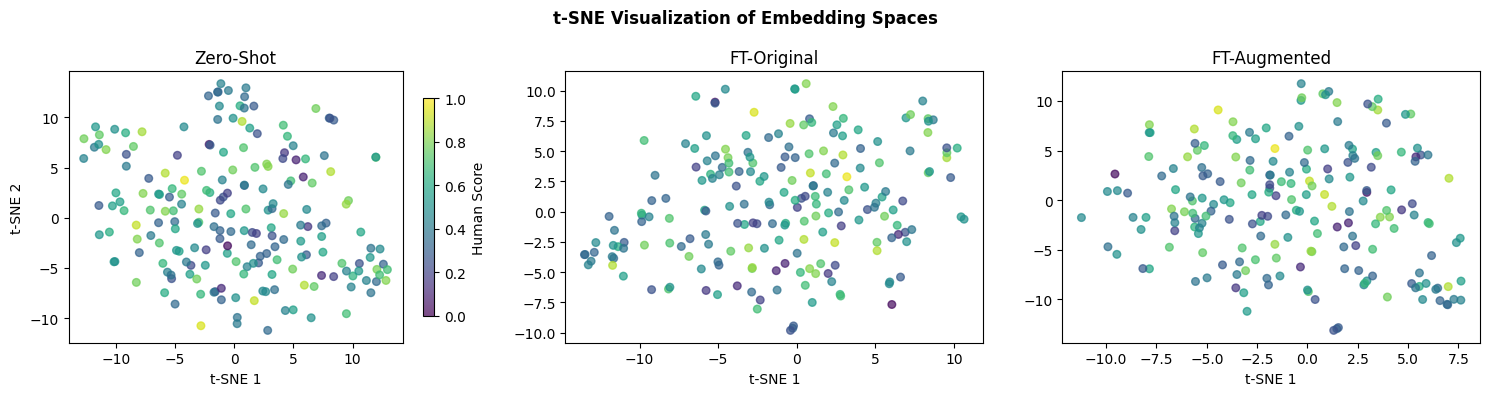

In [ ]:
#4.2. t-SNE Embeddings visualisation

def create_simple_tsne():

    # Sample data
    sample_size = min(200, len(semrel_kin_test))
    sample_indices = np.random.choice(len(semrel_kin_test), sample_size, replace=False)
    sample_df = semrel_kin_test.iloc[sample_indices]
    gold_scores = sample_df['human_score'].values

    models = [
        ("Zero-Shot", "sentence-transformers/LaBSE", None),
        ("FT-Original", LOCAL_OUTPUT_DIR, "finetuned"),
        ("FT-Augmented", LOCAL_OUTPUT_DIR_2, "finetuned")
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for idx, (model_name, model_path, model_type) in enumerate(models):

        # Get embeddings
        if model_type is None:  # Zero-shot
            model = SentenceTransformer(model_path)
            emb1 = model.encode(sample_df['sentence1'].tolist(), show_progress_bar=False)
            emb2 = model.encode(sample_df['sentence2'].tolist(), show_progress_bar=False)
            embeddings = (emb1 + emb2) / 2
        else:  # Fine-tuned
            tokenizer = AutoTokenizer.from_pretrained(model_path)
            model_ft = AutoModel.from_pretrained(model_path).to(DEVICE)
            model_ft.eval()

            with torch.no_grad():
                batch1 = tokenizer(sample_df['sentence1'].tolist(), padding=True, truncation=True, return_tensors="pt").to(DEVICE)
                batch2 = tokenizer(sample_df['sentence2'].tolist(), padding=True, truncation=True, return_tensors="pt").to(DEVICE)
                emb1 = model_ft(**batch1).last_hidden_state[:,0,:].cpu().numpy()
                emb2 = model_ft(**batch2).last_hidden_state[:,0,:].cpu().numpy()
            embeddings = (emb1 + emb2) / 2

        # Apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        embeddings_2d = tsne.fit_transform(embeddings)

        # Plot
        scatter = axes[idx].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                                  c=gold_scores, cmap='viridis', alpha=0.7,
                                  vmin=0, vmax=1, s=30)
        axes[idx].set_title(model_name)
        axes[idx].set_xlabel('t-SNE 1')
        if idx == 0:
            axes[idx].set_ylabel('t-SNE 2')
            plt.colorbar(scatter, ax=axes[idx], shrink=0.8).set_label('Human Score')

    plt.suptitle('t-SNE Visualization of Embedding Spaces', fontweight='bold')
    plt.tight_layout()
    plt.show()

create_simple_tsne()